In [1]:
import pandas as pd
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def extract_last_second_line_metrics(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        lines = file.readlines()
    
    # The second last line
    line = lines[-2]
    
    # Regex to capture val_loss, train_time, step_avg
    val_loss_pattern = r"val_loss:\s*([\d\.e+-]+)"
    train_time_pattern = r"train_time:\s*([\d\.e+-]+)"
    step_avg_pattern = r"step_avg:\s*([\d\.e+-]+)"
    
    val_loss_match = re.search(val_loss_pattern, line)
    train_time_match = re.search(train_time_pattern, line)
    step_avg_match = re.search(step_avg_pattern, line)
    
    val_loss = float(val_loss_match.group(1)) if val_loss_match else None
    train_time = float(train_time_match.group(1)) if train_time_match else None
    step_avg = float(step_avg_match.group(1)) if step_avg_match else None
    
    return val_loss, train_time, step_avg

def get_stats(path):
    last_second_metrics = []
    parent_directory = path
    for file_name in os.listdir(parent_directory):
        file_path = os.path.join(parent_directory, file_name)
        metrics = extract_last_second_line_metrics(file_path)
        if all(m is not None for m in metrics):  # Ensure valid metrics
            last_second_metrics.append(metrics)
    # Convert to a DataFrame for easier calculation
    df = pd.DataFrame(last_second_metrics, columns=["val_loss", "train_time", "step_avg"])
    df['train_time'] = df['train_time']/1000/60
    # Calculate mean and variance for each metric
    final_metrics = {
        "val_loss": {"mean": df["val_loss"].mean(), "variance": df["val_loss"].var()},
        "train_time": {"mean": df["train_time"].mean(), "variance": df["train_time"].var()},
        "step_avg": {"mean": df["step_avg"].mean(), "variance": df["step_avg"].var()},
    }
    return df, final_metrics

# Define a function to plot a grouped boxplot
def plot_grouped_boxplot(data, value_col, ylabel, title):
    plt.figure(figsize=(10, 6))
    sns.violinplot(data=data, hue="source", y=value_col, inner="point", palette="muted")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()


In [3]:
bidirectional_df, bidirectional_metrics = get_stats('./bidirectional')
bidirectional_df['source'] = 'bidirectional_records'
MFUTweaks_df, MFUTweaks_metrics = get_stats('./MFUTweaks')
MFUTweaks_df['source'] = 'MFUTweaks_record'
combined_df = pd.concat([bidirectional_df, MFUTweaks_df], ignore_index=True)

In [4]:
combined_df

,val_loss,train_time,step_avg,source
0,3.2792,39.532267,1613.56,bidirectional_records
1,3.2766,39.545117,1614.09,bidirectional_records
2,3.2794,39.571433,1615.16,bidirectional_records
3,3.2793,39.575267,1615.32,bidirectional_records
4,3.2793,39.576133,1615.35,bidirectional_records
5,3.2769,39.520767,1613.09,bidirectional_records
6,3.2777,39.520650,1613.09,bidirectional_records
7,3.2779,39.570800,1615.13,bidirectional_records
8,3.2770,39.562183,1614.78,bidirectional_records
9,3.2806,39.521633,1613.13,bidirectional_records


In [5]:
bidirectional_metrics

{'val_loss': {'mean': np.float64(3.27874),
  'variance': np.float64(2.0697142857144197e-06)},
 'train_time': {'mean': np.float64(39.55079666666667),
  'variance': np.float64(0.0006340809603174658)},
 'step_avg': {'mean': np.float64(1614.3173333333334),
  'variance': np.float64(1.0563638095237773)}}

In [6]:
MFUTweaks_metrics

{'val_loss': {'mean': np.float64(3.2785866666666665),
  'variance': np.float64(2.8883809523810137e-06)},
 'train_time': {'mean': np.float64(39.56495444444444),
  'variance': np.float64(0.0004544262486773232)},
 'step_avg': {'mean': np.float64(1614.8966666666668),
  'variance': np.float64(0.7535380952381504)}}

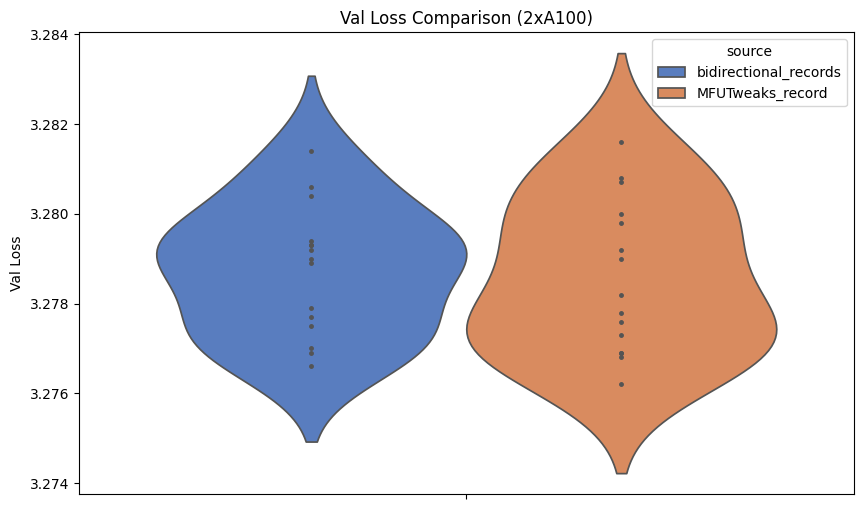

In [7]:
plot_grouped_boxplot(combined_df, "val_loss", "Val Loss", "Val Loss Comparison (2xA100)")

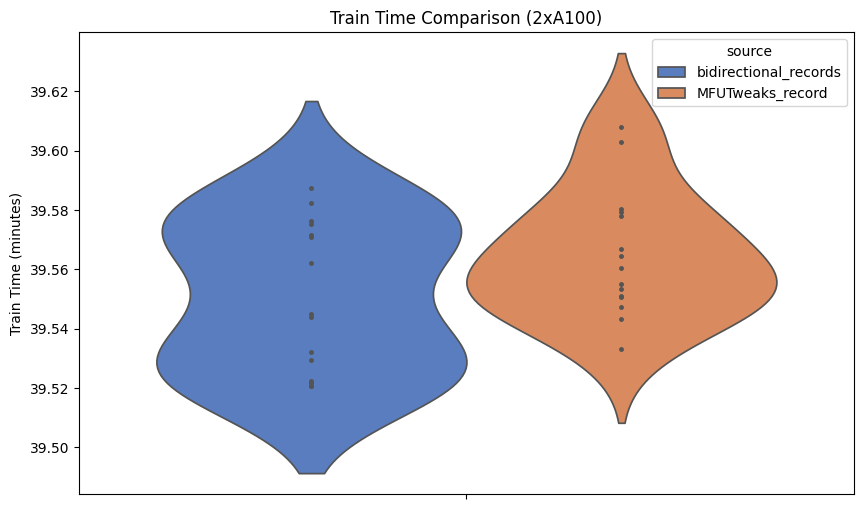

In [8]:
plot_grouped_boxplot(combined_df, "train_time", "Train Time (minutes)", "Train Time Comparison (2xA100)")